# Causal Inference Example - Difference in Differences

This notebook goes through an example of one causal inference method - __difference in differences (DiD)__ - applied to a business scenario.

#### Table of contents
1. [What is DiD and why?](#1-what-is-did-and-why)
2. [Scenario and Setup](#2-scenario-and-setup)
3. [Assessing for parallel trend](#3-assessing-for-parallel-trend)
3. [Calculating the Estimator](#4-calculating-the-estimator)
5. [Conclusion](#5-conclusion)
6. [References](#6-references)



***
## 1. What is DiD and why?

DiD is a causal inference method (a way of establishing causality between an event and an outcome) that compares changes in outcomes over time between a treatment group and a control group. Formally, this __DiD estimator__ is defined as:

$$\hat{\delta}_{DiD} = \underbrace{(\bar{Y}_{treated,post} - \bar{Y}_{treated,pre})}_{\text{change in treated group}} - \underbrace{(\bar{Y}_{control,post} - \bar{Y}_{control,pre})}_{\text{change in control group}}$$

$$\text{where:}$$
$$\bar{Y}_{group,time} \text{ refers to the average outcome for either the control or treatment group, at the time of pre-treatment or post-treatment}$$

Or re-framming as a regression model (i.e. an expression for expected outcome):

$$Y_{it} = \alpha + \beta_1 \text{Treated}_i + \beta_2 \text{Post}_t + \delta(\text{Treated}_i \times \text{Post}_t) + \varepsilon_{it}$$

$$\text{where:}$$
$$Y_{it} = \text{outcome for unit } i \text{ at time } t$$
$$\text{Treated}_i \in \{0,1\} = \text{treatment group indicator}$$
$$\text{Post}_t \in \{0,1\} = \text{post-treatment period indicator}$$
$$\delta = \text{DiD estimator (coefficient of interest)}$$
$$\varepsilon_{it} = \text{error term}$$

The DiD estimator $\hat{\delta}_{DiD}$ estimates the __Average Treatment Effect (ATT)__ by assuming that pre-treatment, both control and treated groups following the same trend. This is the __parallel trends assumption__. Through this, we are trying to make up for the fact that one key term - the post-treatment outcome for the treated group _if they were never treated_ (or __counterfactual__) - is impossible to measure by definition.
__________________
### Why DiD?

This sounds eerily familiar to A/B tests - why not always run those instead? While randomized controlled trials (of which A/B testing is an example of) is the well-known as the gold standard for causal inference, sometimes practical constraints mean DiD is the preferred method. These include:
* When randomized samples are either impossible or unethical. For example, assessing the effect of a real-world policy change. We can't exactly randomly sort different cities into control and treatment groups!
* When RCT is too expensive or slow. For example, A/B testing often requires complex instrumentation, data capture, and the experiment to run for 2+ weeks to eliminate seasonality bias.
* When the treatment has already happened. DiD is retrospective by nature (using previously captured longitudinal data), whereas RCT requires prospective planning before experimentation can even begin.

***
## 2. Scenario and Setup

YourWorkoutMate launched a new AI personal trainer (PT) for premium users 7 months ago. Currently, it has only rolled the feature out to Australia and wants to gradually roll out the feature to other regions. The product team wants to understand the effect that this new AI personal trainer has had on average revenue per user (ARPU), and have engaged you - their resident data science guru - to help ascertain the commercial impact of this new feature.

Given that it is a new release and being rolled out by region, running an A/B test on the feature is impossible. So instead, you set your eyes on using a Difference-in-Difference approach to estimate the treatment effect of the feature.

***
To start, we're going to generate some data for our scenario using a custom library - [diff_diff](https://diff-diff.readthedocs.io/en/stable/).

In [1]:
# !pip install diff-diff

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from diff_diff import (
    DifferenceInDifferences,
    generate_did_data,
)

In [2]:
data_2x2 = generate_did_data(
    n_units=100,
    n_periods=12, # 12 months of history
    treatment_effect=5.0, # True treatment effect
    treatment_period=8, # Treatment was introduced 5 months ago... 12, 11, 10, 9, 8
    treatment_fraction=0.5,
    seed=7, # Fixed random seed for reproducibility
)

# Renaming to align to our scenario
data_2x2.columns = ['user', 'period', 'group', 'post', 'rev', 'true_effect']

print(f"Dataset size: {data_2x2.shape[0]} | # columns: {data_2x2.shape[1]}")
print( f"\n {data_2x2.head(12)}" )

Dataset size: 1200 | # columns: 6

     user  period  group  post        rev  true_effect
0      0       0      1     0   9.697983          0.0
1      0       1      1     0   9.602533          0.0
2      0       2      1     0  11.166513          0.0
3      0       3      1     0  13.747217          0.0
4      0       4      1     0  11.170737          0.0
5      0       5      1     0  11.878517          0.0
6      0       6      1     0  13.207864          0.0
7      0       7      1     0  13.995474          0.0
8      0       8      1     1  18.826054          5.0
9      0       9      1     1  19.296530          5.0
10     0      10      1     1  20.704923          5.0
11     0      11      1     1  21.022368          5.0


Each row pertains to one user in one month out of the last 12, alongside:
* $group$ - whether the user was in the control (0) or treatment (1) group. In our scenario, "treatment" refers to Australian users who had access to the AI PT
* $post$ - whether the user's period was pre (0) or post-treatment (1)
* $rev$ - what the user brought in revenue for that period (premium subscriptions, in-app ad watchtime)

Per below, the generated data fits uniformly based on what group they're in and whether it's pre or post-treatment. This will introduce less standard error than if the data was heavily imbalanced, giving our DiD estimator more statistical power. In reality, such data will rarely be uniform.

In [3]:
pd.crosstab(data_2x2["group"], data_2x2["post"], margins=True)

post,0,1,All
group,,,
0,400,200,600
1,400,200,600
All,800,400,1200


Visualizing the data with boxplots:

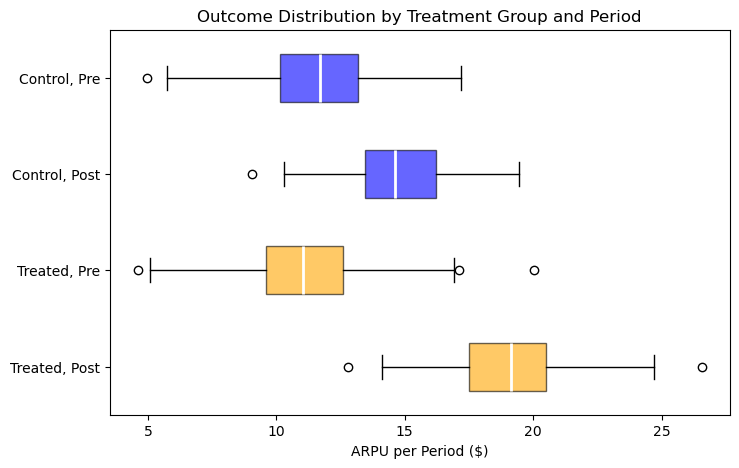

,group,median,mean
0,"Control, Pre",11.685877,11.616620
1,"Control, Post",14.612231,14.692168
2,"Treated, Pre",11.016048,11.059731
3,"Treated, Post",19.151151,19.080019


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

groups = [
    ("Control, Pre",  data_2x2[(data_2x2["group"] == 0) & (data_2x2["post"] == 0)]["rev"]),
    ("Control, Post", data_2x2[(data_2x2["group"] == 0) & (data_2x2["post"] == 1)]["rev"]),
    ("Treated, Pre",  data_2x2[(data_2x2["group"] == 1) & (data_2x2["post"] == 0)]["rev"]),
    ("Treated, Post", data_2x2[(data_2x2["group"] == 1) & (data_2x2["post"] == 1)]["rev"]),
]

bp = ax.boxplot(
    [g[1] for g in groups],
    tick_labels=[g[0] for g in groups],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    vert=False # horizontal
    #, showfliers=False # outliers
)
ax.invert_yaxis()

box_colors = ['blue', 'blue', 'orange', 'orange']
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xlabel("ARPU per Period ($)")
ax.set_title("Outcome Distribution by Treatment Group and Period")

plt.show()

pd.DataFrame({
    'group':  [g[0] for g in groups],
    'median': [g[1].median() for g in groups],
    'mean':   [g[1].mean()   for g in groups],
})

There is visual evidence of a treatment effect; we can see the control median outcome (revenue) moves from $11.69 -> $14.61 in the control group, whereas the treatment group's outcome moves from $11.02 -> $19.15. Under DiD estimation, we'll essentially assume that the former movement is a parallel trend that would be the treatment group's counterfactual outcome, and the treatment effect is the remaining difference.

Note that spread looks similar across all 4 boxplots, suggesting that treatment positively affects outcome but does not increase variability.

***
## 3. Assessing for parallel trend

Now to check that the key assumption holds - do both control and treatment groups follow a similar historical trend pre-treatment?

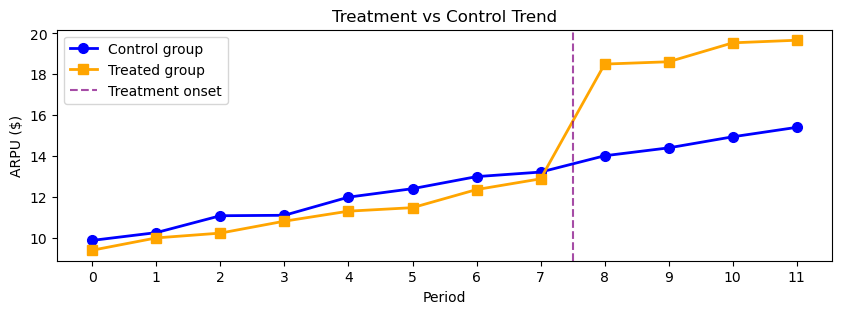

Correlation coefficient: 0.98


In [5]:
treated_means = data_2x2[data_2x2["group"] == 1].groupby("period")["rev"].mean()
control_means = data_2x2[data_2x2["group"] == 0].groupby("period")["rev"].mean()

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(control_means.index, control_means.values, "o-", color='blue', linewidth=2, markersize=7, label="Control group")
ax.plot(treated_means.index, treated_means.values, "s-", color='orange', linewidth=2, markersize=7, label="Treated group")
ax.axvline(x=7.5, color='purple', linestyle="--", linewidth=1.5, alpha=0.7, label="Treatment onset")
ax.set_xlabel("Period")
ax.set_ylabel("ARPU ($)")
ax.set_title("Treatment vs Control Trend")
ax.legend(loc="upper left")
ax.set_xticks(range(12))

plt.show()

df_ctrl_rev = data_2x2[(data_2x2['group'] == 0) & (data_2x2['post'] == 0)].groupby('period')['rev'].mean()
df_treat_rev = data_2x2[(data_2x2['group'] == 1) & (data_2x2['post'] == 0)].groupby('period')['rev'].mean()
print( f'Correlation coefficient: {df_ctrl_rev.corr(df_treat_rev):.2f}')

By visual inspection, the parallel trends assumption holds; periods 0 - 7 are highly correlated with only slight variability. The __~0.98 correlation coefficient__ between each group exemplifies this.

***
## 4. Calculating the Estimator

Let's apply the DiD estimator. The below function estimates the ATT by fitting an OLS regression of the form rev ~ group * post, where the coefficient on the interaction term is our estimate δ̂.

In [6]:
did = DifferenceInDifferences()
results_2x2 = did.fit(data_2x2, outcome='rev', treatment='group', time='post')
results_2x2.print_summary()

             Difference-in-Differences Estimation Results             

Observations:                   1200
Treated:                         600
Control:                         600
R-squared:                    0.6348

----------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
----------------------------------------------------------------------
ATT                   4.9447       0.2635     18.765     0.0000   ***
----------------------------------------------------------------------

95% Confidence Interval: [4.4278, 5.4617]

Signif. codes: '***' 0.001, '**' 0.01, '*' 0.05, '.' 0.1


The estimated ATT is $4.94, with stand error of 0.26. The p-value being well below < 0.05 confirm that the effect is highly statistically significant, with the 95% confidence interval ranging from $4.42 to $5.46.

Using the DiD estimator, we can reconstruct the counterfactual by projecting the control group’s post-treatment trajectory, shifted up by the pre-treatment gap between the groups. The shaded area between the actual treated outcomes and this counterfactual line represents the estimated causal effect.

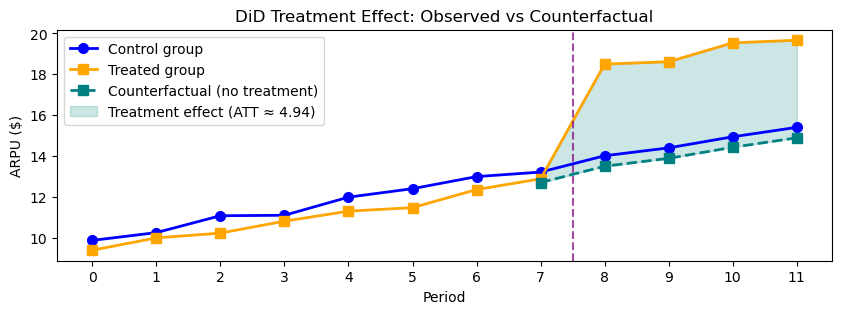

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(control_means.index, control_means.values, "o-", color='blue', linewidth=2, markersize=7, label="Control group")
ax.plot(treated_means.index, treated_means.values, "s-", color='orange', linewidth=2, markersize=7, label="Treated group")

# Counterfactual: treated group without treatment
pre_diff = treated_means.loc[:4].mean() - control_means.loc[:4].mean()
counterfactual = control_means.loc[7:] + pre_diff
ax.plot(counterfactual.index, counterfactual.values, "s--",
        color='teal', linewidth=2, markersize=7,
        label="Counterfactual (no treatment)")
ax.fill_between(counterfactual.index, counterfactual.values,
        treated_means.loc[7:].values, alpha=0.2, color='teal',
        label=f"Treatment effect (ATT ≈ {results_2x2.att:.2f})")
ax.axvline(x=7.5, color='purple', linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Period")
ax.set_ylabel("ARPU ($)")
ax.set_title("DiD Treatment Effect: Observed vs Counterfactual")
ax.legend(loc="upper left")
ax.set_xticks(range(12))

plt.show()

__Alternative method:__ statsmodels can perform the same regression, since it is simply an OLS fit per the terms laid out in [section 1](#1-what-is-did-and-why). Furthermore, you can get a quick and dirty DiD estimator value using the simplified expected value formula.

In [10]:
from statsmodels.formula.api import ols

data_2x2['group_post'] = data_2x2['group'] * data_2x2['post']
data_alt = data_2x2[['rev', 'group', 'post', 'group_post']].copy()

ols = ols('rev ~ group + post + group_post', data=data_alt).fit()
# using cov_type = 'HC3' aligns to DifferencesInDifferences(), which uses robust se instead of homoskedastic
print(ols.summary())

ATT_estimate = (
    (groups[3][1].mean() - groups[2][1].mean() ) # Change in treated group
    - (groups[1][1].mean() - groups[0][1].mean()) # Change in control group
)
print( f'___\nQuick ATT estimate: {ATT_estimate}')

                            OLS Regression Results                            
Dep. Variable:                    rev   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     693.1
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          5.12e-261
Time:                        17:55:52   Log-Likelihood:                -2654.7
No. Observations:                1200   AIC:                             5317.
Df Residuals:                    1196   BIC:                             5338.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.6166      0.111    104.922      0.0

***
## 5. Conclusion

You report back to the product team that the AI PT has on average increased ARPU per period by almost $5 in Australia compared to if it was not launched there. From there, the team is thankful, but engages you to further understand the applicability to rollout in South East Asia.

***
## 6. References

* [Facure Alves, M. (2022) <i>Causal Inference for the Brave and True</i>, GitHub](https://matheusfacure.github.io/python-causality-handbook/13-Difference-in-Differences.html)

* [Mendez, C. (2026) <i>Introduction to Difference-in-Differences in Python</i>, Carlos Mendez](https://carlos-mendez.org/post/python_did/)

* [Wang, H. (2022) <i>Differences-in-Differences in Python</i>, Kaggle](https://www.kaggle.com/code/harrywang/difference-in-differences-in-python)